<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/Analyse_image_spectre_2D_en_longueur_d_onde_et_arcsec(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- 1. Installation des dépendances ---
!pip install astropy -q

In [ ]:
# --- 2. Import des bibliothèques ---
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from google.colab import files
from scipy.interpolate import interp1d

In [ ]:
# --- 3. Upload du fichier FITS ---
print("Sélectionner le fichier fits 2D _objet issu du traitement Isis  :")
uploaded = files.upload()
fits_file = list(uploaded.keys())[0]



Sélectionner le fichier fits 2D _objet issu du traitement Isis  :


Saving _M1_nuit2_30pixcenter.fit to _M1_nuit2_30pixcenter.fit


In [ ]:
# --- 4. Polynôme de calibration ISIS (Alpy 600) ---
def pixel_to_wavelength(x):
    A0 =  2890.605
    A1 =  3.3178208
    A2 =  0.0006049546
    A3 = -5.154625e-07
    A4 =  1.132926e-10
    return A0 + A1*x + A2*x**2 + A3*x**3 + A4*x**4


In [ ]:
# --- 5. Chargement de l'image FITS ---
with fits.open(fits_file) as hdul:
    image = hdul[0].data

ny, nx = image.shape
print(f"Dimensions : {image.shape}")

Dimensions : (1039, 1391)


In [ ]:
# --- 6. Axe spectral non linéaire ---
pixels = np.arange(nx)
wavelengths = pixel_to_wavelength(pixels)

In [ ]:
# --- 7. Axe spatial & rééchantillonnage spectral ---

arcsec_per_pixel = 1.478  # (taille pixel µm / focale mm) × 206265

# Grille λ linéaire cible (nx points entre λ_min et λ_max)
wl_lin = np.linspace(wavelengths[0], wavelengths[-1], nx)

# Rééchantillonnage X : on interpole chaque ligne depuis la grille
# non-linéaire 'wavelengths' (issue du polynôme d'ordre 4) vers wl_lin
image_resampled = np.zeros_like(image)
for row in range(ny):
    f = interp1d(wavelengths, image[row, :],
                 kind='linear',
                 bounds_error=False,
                 fill_value=0)
    image_resampled[row, :] = f(wl_lin)

# Axe Y : pas de rééchantillonnage — la fente est linéaire par nature.
# On détecte le centre (max du profil spatial) et on convertit en arcsec.
profil_spatial = np.sum(image_resampled, axis=1)
center_row = np.argmax(profil_spatial)
arcsec = (np.arange(ny) - center_row) * arcsec_per_pixel

print(f"Centre détecté (pixel Y) : {center_row}")
print(f"Plage spectrale : {wl_lin[0]:.1f} – {wl_lin[-1]:.1f} Å  ({nx} pixels, pas {wl_lin[1]-wl_lin[0]:.3f} Å)")
print(f"Plage spatiale  : {arcsec[0]:.1f} – {arcsec[-1]:.1f} arcsec")


Centre détecté (pixel Y) : 464
Plage spectrale : 2890.6 – 7709.8 Å  (1391 pixels, pas 3.467 Å)
Plage spatiale  : -685.8 – 848.4 arcsec


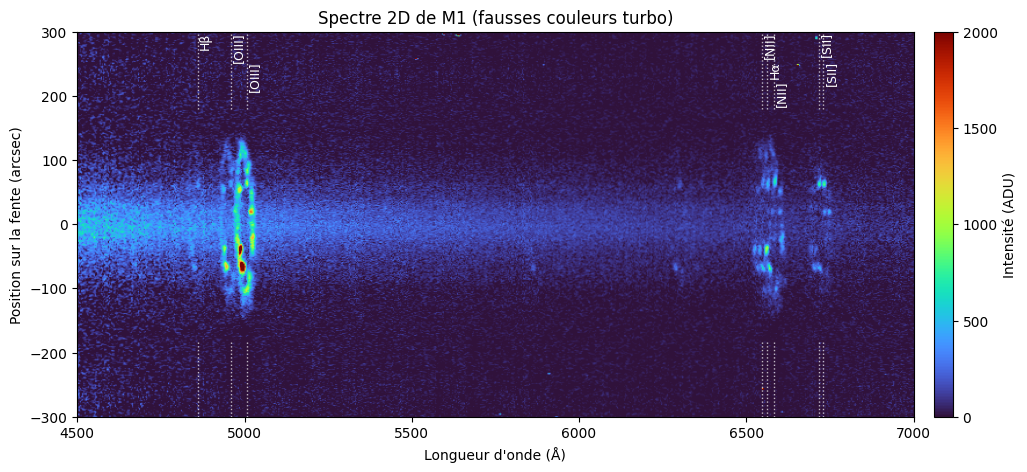

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# --- 9. Affichage fausses couleurs (turbo) ---
fig, ax = plt.subplots(figsize=(13,5))

vmin_plot = 0    # ADU → bleu (fond)
vmax_plot = 2000  # ADU → rouge (max)

extent = [wl_lin[0], wl_lin[-1], arcsec[0], arcsec[-1]]

im = ax.imshow(
    image_resampled,
    origin='lower',
    aspect='auto',
    extent=extent,
    cmap='turbo',
    vmin=vmin_plot,
    vmax=vmax_plot
)

# --- Zoom spectral & spatial ---
ax.set_xlim(4500, 7000)
ax.set_ylim(-300, 300)

# --- Raies principales ---
raies = {
    "Hβ": 4861.33,
    "[OIII]": 4958.91,
    "[OIII] ": 5006.84,
    "Hα": 6562.80,
    "[NII]": 6548.05,
    "[NII] ": 6583.45,
    "[SII]": 6716.44,
    "[SII] ": 6730.82,
}

raies_triees = sorted(raies.items(), key=lambda x: x[1])
levels = [1, 0.85, 0.75, 0.65]
last_lam = None
level = 0

ymin, ymax = ax.get_ylim()
dy = (ymax - ymin) * 0.2

for nom, lam in raies_triees:
    if 3800 < lam < 7000:
        if last_lam is not None and abs(lam - last_lam) < 80:
            level += 1
        else:
            level = 0
        y = ymax * levels[level % len(levels)]
        ax.plot([lam, lam], [ymin, ymin + dy], color='white', linestyle=':', linewidth=1, alpha=0.7)
        ax.plot([lam, lam], [ymax - dy, ymax], color='white', linestyle=':', linewidth=1, alpha=0.7)
        ax.text(lam + 3, y, nom.strip(),
                color='white', fontsize=9, rotation=90, va='top', ha='left')
        last_lam = lam

ax.set_xlabel("Longueur d'onde (Å)")
ax.set_ylabel("Position sur la fente (arcsec)")
ax.set_title("Spectre 2D de M1 (fausses couleurs turbo)")

# --- Colorbar ADU ---
cbar = fig.colorbar(im, ax=ax, pad=0.02)
ticks = np.linspace(vmin_plot, vmax_plot, 5)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{int(t)}" for t in ticks])
cbar.set_label("Intensité (ADU)")

# --- Sauvegarde & téléchargement ---
output_name = "spectre_2D_turbo.png"
fig.savefig(output_name, dpi=300, bbox_inches='tight')
plt.show()
from google.colab import files
files.download(output_name)


# Mesure de la position des raies [OIII]

# Analyse dans VSpec

mesure ajustement gaussienne
- pic blue shift 4980.7 A
- pic red shift 5026.4 A


In [ ]:
    c_km_s = 299790 # vitesse de la lumière
    lam_ref_5007 = 5006.84 # raie [OIII] au repos donnée laboratoire

    lam_blue = 4980.7 # mesure dans Visuel Spec (fit 1 gaussienne)
    lam_red  = 5026.4 # mesure dans Visuel Spec (fit 1 gaussienne)

    v_blue = c_km_s * (lam_blue - lam_ref_5007) / lam_ref_5007
    v_red  = c_km_s * (lam_red  - lam_ref_5007) / lam_ref_5007
    v_exp  = (v_red - v_blue) / 2   # vitesse d'expansion

    print(f"Composante bleue  : {lam_blue:.1f} Å  →  v = {v_blue:+.0f} km/s")
    print(f"Composante rouge  : {lam_red:.1f} Å  →  v = {v_red:+.0f} km/s")
    print(f"Vitesse expansion : {v_exp:.0f} km/s")

Composante bleue  : 4980.7 Å  →  v = -1565 km/s
Composante rouge  : 5026.4 Å  →  v = +1171 km/s
Vitesse expansion : 1368 km/s
